In [10]:
from owlready2 import get_ontology
import re
import numpy as np
import pandas as pd
import os
from scipy.spatial.distance import cosine
from openai import OpenAI
import time
from matplotlib import pyplot as plt

# —— configure your billing rates here (USD per 1K tokens) ——
EMBEDDING_PRICE_PER_1K_TOKENS   = 0.00013
COMP_PROMPT_PRICE_PER_1K_TOKENS = 0.0025  # $2.50 ÷ 1000
COMP_RESP_PRICE_PER_1K_TOKENS   = 0.01    # $10.00 ÷ 1000

# instantiate client
client = OpenAI(api_key='YOUR APEN API KEY')

# global trackers
_embedding_costs  = []
_embedding_times  = []
_completion_costs = []
_completion_times = []

def get_embedding(text, model="text-embedding-3-large"):
    start = time.time()
    resp = client.embeddings.create(input=[text.replace("\n"," ")], model=model)
    dt = time.time() - start

    toks = resp.usage.total_tokens
    cost = (toks / 1000) * EMBEDDING_PRICE_PER_1K_TOKENS

    _embedding_times.append(dt)
    _embedding_costs.append(cost)

    return resp.data[0].embedding

def get_response(prompt):
    start = time.time()
    resp = client.chat.completions.create(
        model="gpt-4o-2024-08-06",
        messages=[{"role":"user",
                   "content": f"Please use 1 sentence to describe cell type: {prompt}"}]
    )
    dt = time.time() - start

    p_toks = resp.usage.prompt_tokens
    c_toks = resp.usage.completion_tokens
    cost = (p_toks/1000)*COMP_PROMPT_PRICE_PER_1K_TOKENS + (c_toks/1000)*COMP_RESP_PRICE_PER_1K_TOKENS

    _completion_times.append(dt)
    _completion_costs.append(cost)

    return resp.choices[0].message.content.strip()

# — your original ontology & data loading —

work_pth = os.getcwd()
onto = get_ontology(os.path.join(work_pth, "data", "cl_20250129.owl")).load()

labels_all = []
for cls in onto.classes():
    if cls.label and re.match(r"CL", cls.name):
        labels_all.append(cls.label[0])

with open(os.path.join(work_pth, "data", "HRA_cell_type.txt")) as f:
    hra_list = [l.strip() for l in f]

hra_cell_type = sorted(
    [lbl for lbl in labels_all if lbl.casefold() in {x.casefold() for x in hra_list}]
)

embeddings            = np.genfromtxt(os.path.join(work_pth, "data", "embeddings_all_CL.txt"),       delimiter=",")
embeddings_response   = np.genfromtxt(os.path.join(work_pth, "data", "embeddings_all_C_response.txt"),delimiter=",")
emb_all_dict          = dict(zip(labels_all, embeddings))
emb_resp_dict         = dict(zip(labels_all, embeddings_response))

embeddings_hra          = np.array([emb_all_dict[c]  for c in hra_cell_type])
embeddings_response_hra = np.array([emb_resp_dict[c] for c in hra_cell_type])

def find_closest_cell_type(name, mode="simple", background="CL"):
    arb_emb, best, bd = get_embedding(name), None, float("inf")

    if mode=="simple" and background=="CL":
        pool, labels = embeddings, labels_all
    elif mode=="simple" and background=="HRA":
        pool, labels = embeddings_hra, hra_cell_type
    elif mode=="complex" and background=="CL":
        pool, labels = embeddings_response, labels_all
    else:
        pool, labels = embeddings_response_hra, hra_cell_type

    for lbl, emb in zip(labels, pool):
        d = cosine(arb_emb, emb)
        if d < bd:
            best, bd = lbl, d
    return best, bd

def GPTcelltype_standardizer(input_list, mode="simple", background="HRA"):
    """
    Returns:
      1) standardized_list
      2) total_costs:   [cum_cost_after_1st,…,cum_after_last]
      3) total_times:   [cum_time_after_1st,…,cum_after_last]
    """
    # clear previous logs
    _embedding_costs.clear()
    _embedding_times.clear()
    _completion_costs.clear()
    _completion_times.clear()

    out           = []
    total_costs   = []
    total_times   = []
    cum_cost      = 0.0
    cum_time      = 0.0

    for ct in input_list:
        if mode=="simple":
            gct, _ = find_closest_cell_type(ct, mode, background)
        else:  # complex
            desc = get_response(ct)
            gct, _ = find_closest_cell_type(desc, mode, background)
        out.append(gct)

        # update cumulative sums
        cum_cost = sum(_embedding_costs) + sum(_completion_costs)
        cum_time = sum(_embedding_times) + sum(_completion_times)

        total_costs.append(cum_cost)
        total_times.append(cum_time)

    return out, total_costs, total_times

#if __name__ == "__main__":
#    sample = ["T cell", "B cell", "NK cell"]
#    std, costs, times = GPTcelltype_standardizer(sample, mode="complex")

#    print("Standardized:", std)
#    print("Cumulative costs after each query:  ", costs)
#    print("Cumulative runtimes after each query:", times)


In [2]:
tab = pd.read_excel('~/project/text_embedding_cell_type_gene/41592_2024_2235_MOESM3_ESM.xlsx',sheet_name='Supplementary Table 4',skiprows=3,header=0)
res_tab = pd.read_excel('~/project/text_embedding_cell_type_gene/GPT4_corrected_annotation_Jason_edited.xlsx',header=0)
cell_type = res_tab['manual annotation'].drop_duplicates().tolist()
# cell_type

In [3]:
len(cell_type)

265

In [18]:
std, costs, times = GPTcelltype_standardizer(cell_type, mode="complex")
std2, costs2, times2 = GPTcelltype_standardizer(cell_type, mode="simple")

In [19]:
print(len(costs2),len(costs))

265 265


In [9]:
costs

[0.0025599999999999998,
 0.0050799999999999994,
 0.00754,
 0.011729999999999999,
 0.015170000000000001,
 0.01813,
 0.02123,
 0.02439,
 0.02814,
 0.031349999999999996,
 0.034999999999999996,
 0.03732,
 0.04089,
 0.04522,
 0.04826999999999999,
 0.05191,
 0.05453,
 0.05691,
 0.05983,
 0.06324,
 0.06584,
 0.06871,
 0.07214999999999999,
 0.07505999999999999,
 0.07785,
 0.08094,
 0.0828,
 0.0858,
 0.08829000000000001,
 0.09068999999999999,
 0.094,
 0.09643,
 0.09988,
 0.10307,
 0.10527999999999998,
 0.10786,
 0.11070999999999999,
 0.11429,
 0.11679,
 0.11995,
 0.12232,
 0.12608,
 0.129,
 0.13249999999999998,
 0.13656,
 0.13946,
 0.14205,
 0.14499,
 0.14836,
 0.15098999999999999,
 0.15486,
 0.15798,
 0.1611,
 0.16504,
 0.1693,
 0.17342,
 0.17615999999999998,
 0.17912,
 0.18224,
 0.18536999999999998,
 0.1891,
 0.19227,
 0.19487,
 0.19787,
 0.20045,
 0.20340999999999998,
 0.20658,
 0.21034,
 0.21348999999999999,
 0.217,
 0.21953,
 0.22251,
 0.22557,
 0.22893,
 0.23226999999999998,
 0.2357099999

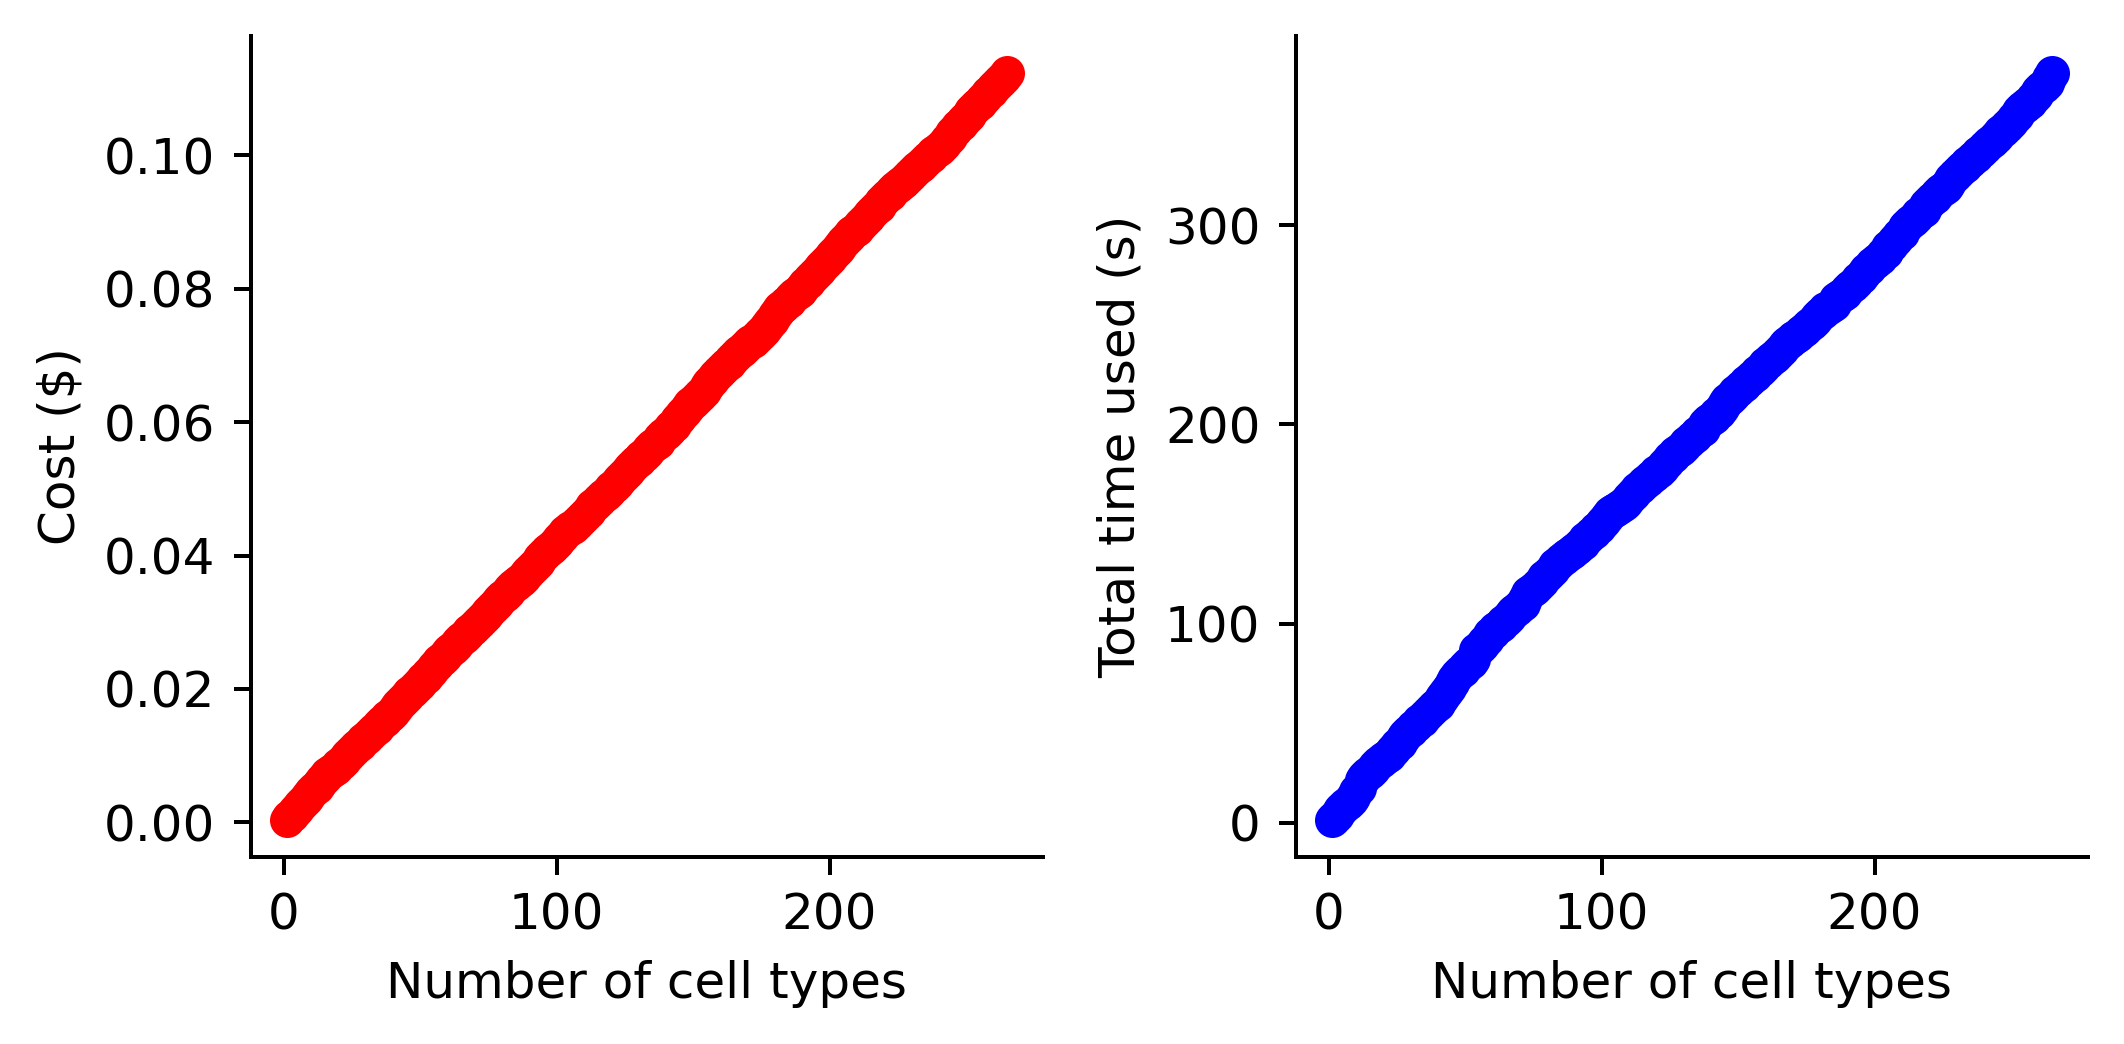

In [17]:
indices = list(range(1, len(costs) + 1))
fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=360)

# Plot 1: Cost
ax = axes[0]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.scatter(indices, costs, color='red')
ax.set_xlabel("Number of cell types")
ax.set_ylabel("Cost ($)")

# Plot 2: Time
ax = axes[1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.scatter(indices, times, color='blue', marker='o')
ax.set_xlabel("Number of cell types")
ax.set_ylabel("Total time used (s)")

plt.tight_layout()
plt.show()

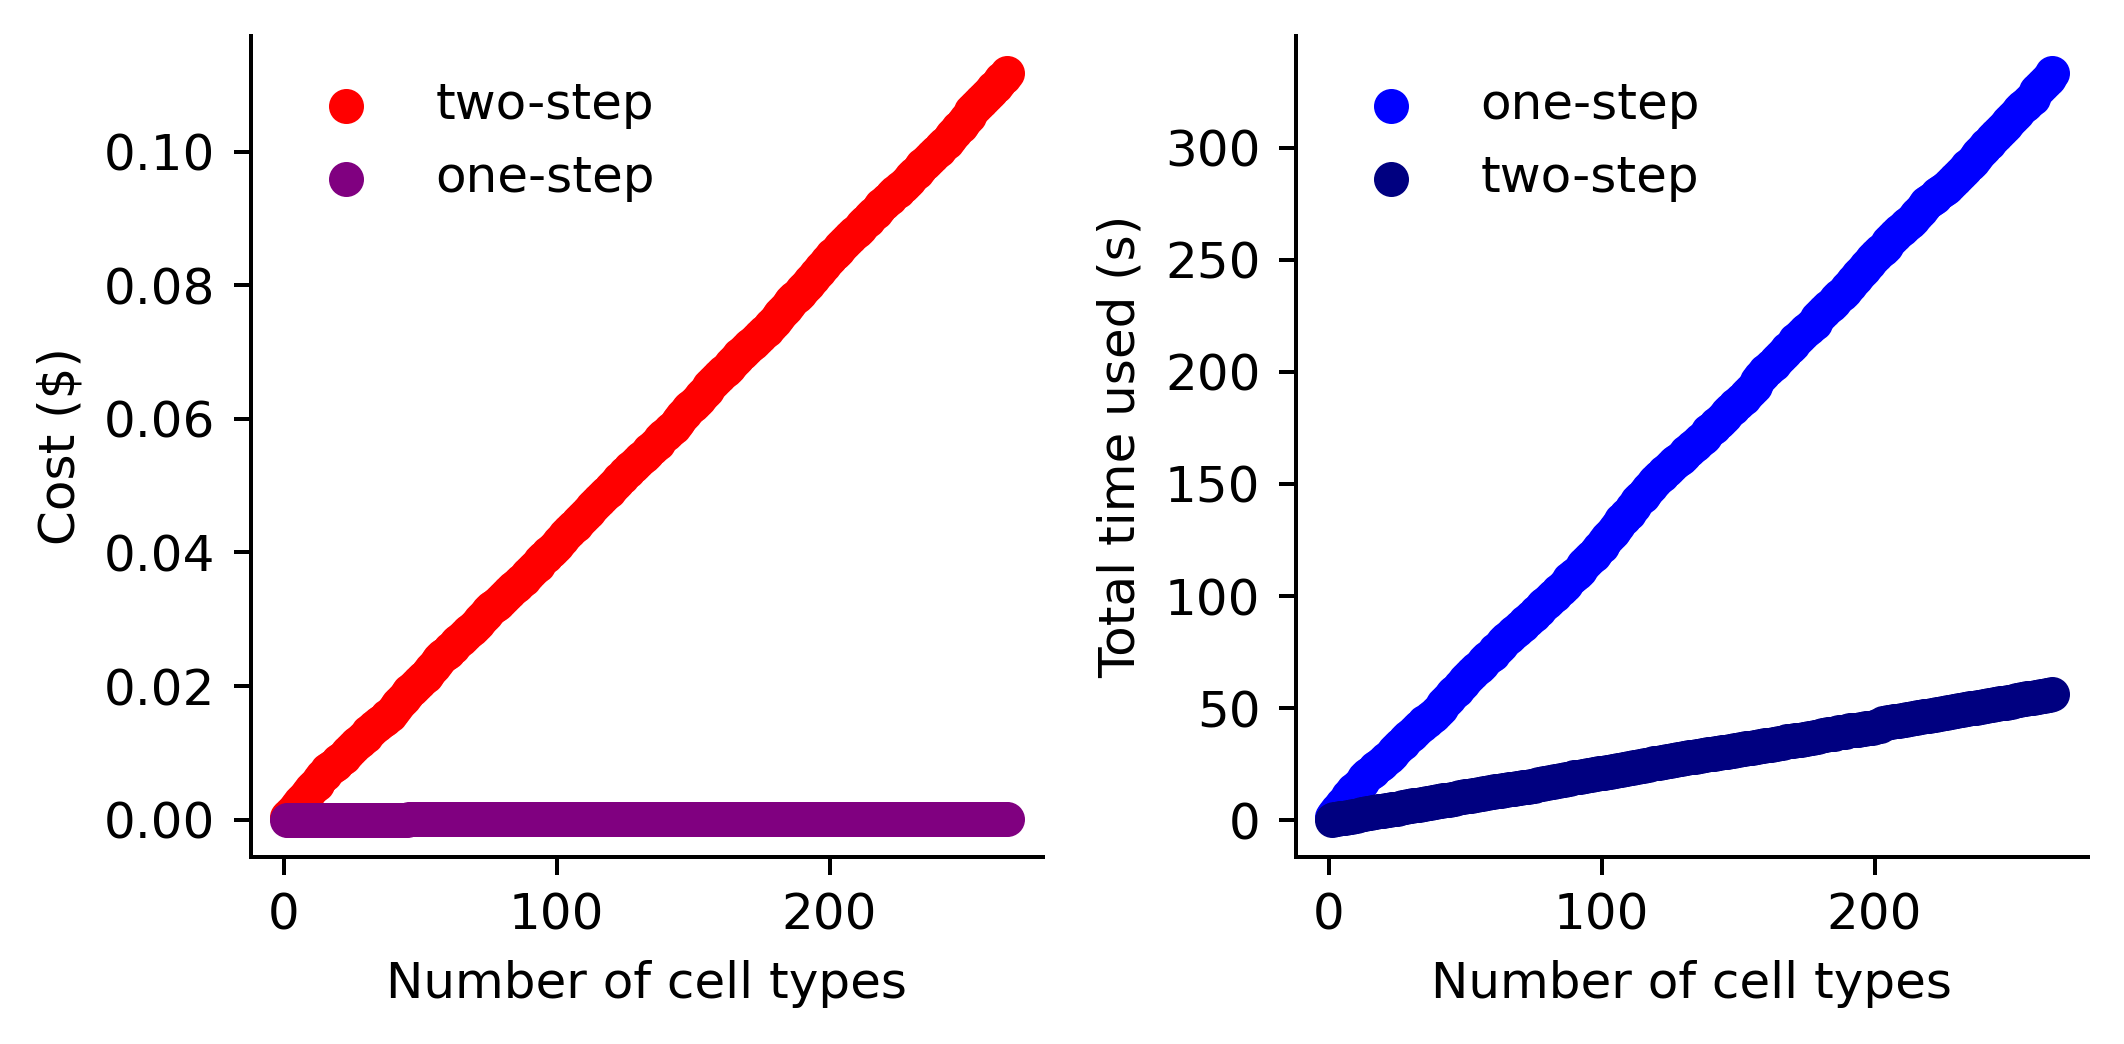

In [24]:
indices = list(range(1, len(costs) + 1))
fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=360)

# ------------------- Plot 1: Cost -------------------
ax = axes[0]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# original
ax.scatter(indices, costs, color='red', label="two-step")

# new line
ax.scatter(indices, costs2, color='purple', label='one-step')

ax.set_xlabel("Number of cell types")
ax.set_ylabel("Cost ($)")
ax.legend(frameon=False)

# ------------------- Plot 2: Time -------------------
ax = axes[1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# original
ax.scatter(indices, times, color='blue', marker='o', label="one-step")

# new line
ax.scatter(indices, times2, color='navy', marker='o',label='two-step')

ax.set_xlabel("Number of cell types")
ax.set_ylabel("Total time used (s)")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [21]:
costs2

[3.8999999999999997e-07,
 9.1e-07,
 1.4299999999999999e-06,
 2.34e-06,
 2.73e-06,
 3.77e-06,
 4.81e-06,
 5.9799999999999995e-06,
 6.629999999999999e-06,
 7.409999999999999e-06,
 8.32e-06,
 8.58e-06,
 9.1e-06,
 9.88e-06,
 1.0399999999999999e-05,
 1.0919999999999999e-05,
 1.131e-05,
 1.183e-05,
 1.2349999999999999e-05,
 1.2869999999999999e-05,
 1.3389999999999999e-05,
 1.3909999999999999e-05,
 1.4429999999999999e-05,
 1.4819999999999999e-05,
 1.534e-05,
 1.586e-05,
 1.638e-05,
 1.768e-05,
 1.846e-05,
 1.9109999999999998e-05,
 2.0019999999999998e-05,
 2.041e-05,
 2.158e-05,
 2.1839999999999998e-05,
 2.223e-05,
 2.2749999999999997e-05,
 2.314e-05,
 2.34e-05,
 2.366e-05,
 2.4829999999999998e-05,
 2.4959999999999998e-05,
 2.5609999999999997e-05,
 2.6649999999999997e-05,
 2.704e-05,
 2.743e-05,
 2.7689999999999997e-05,
 2.821e-05,
 2.899e-05,
 2.925e-05,
 2.9639999999999997e-05,
 3.016e-05,
 3.055e-05,
 3.094e-05,
 3.1849999999999995e-05,
 3.328e-05,
 3.432e-05,
 3.523e-05,
 3.549e-05,
 3.587

## accurary and runtime tradeoff

In [13]:
# std_hra, costs_hra, times_hra = GPTcelltype_standardizer(cell_type, mode="complex",background='HRA')
std_cl, costs_cl, times_cl = GPTcelltype_standardizer(cell_type, mode="complex",background='CL')

In [14]:
# hra_dict = dict(zip(cell_type,std_hra))
cl_dict = dict(zip(cell_type,std_cl))

In [15]:
merged_tab = tab.merge(res_tab.drop('manual CLname',axis=1),on = 'manual annotation',how='inner')
merged_tab = merged_tab.drop_duplicates(subset = ['dataset','tissue','manual annotation'])
# std_hra_col = [hra_dict[x] for x in merged_tab['manual annotation']]
std_cl_col = [cl_dict[x] for x in merged_tab['manual annotation']]

In [16]:
merged_tab['GPT-4 corrected annotation(complex with CL background)'] = std_cl_col
merged_tab

,dataset,tissue,marker,manual annotation,manual CLname,manual CLID,manual broadtype,"GPT-4 (June 13, 2023) annotation","GPT-4 (June 13, 2023) CLname","GPT-4 (June 13, 2023) CLID",...,ScType annotation,ScType CLname,ScType CLID,ScType broadtype,ScType agreement,GPT-4 corrected annotation(simple),GPT-4 corrected annotation(complex),label for simple strategy,label for complex strategy,GPT-4 corrected annotation(complex with CL background)
0,Azimuth,PBMC,"MS4A1, TNFRSF13B, IGHM, IGHD, AIM2, CD79A, LIN...",Intermediate B cell,transitional stage B cell,CL:0000818,b cell,B Cells,B cell,CL:0000236,...,NaN,NaN,NaN,NaN,NaN,B-2 B cell,transitional stage B cell,partial mismatch,fully match,transitional stage B cell
1,Azimuth,PBMC,"MS4A1, COCH, AIM2, BANK1, SSPN, CD79A, TEX9, R...",Memory B cell,memory B cell,CL:0000787,b cell,B Cells,B cell,CL:0000236,...,NaN,NaN,NaN,NaN,NaN,memory B cell,memory B cell,fully match,fully match,memory B cell
2,Azimuth,PBMC,"IGHM, IGHD, CD79A, IL4R, MS4A1, CXCR4, BTG1, T...",Naive B cell,naive B cell,CL:0000788,b cell,B Cells,B cell,CL:0000236,...,NaN,NaN,NaN,NaN,NaN,naive B cell,naive B cell,fully match,fully match,naive B cell
3,Azimuth,PBMC,"IGHA2, MZB1, TNFRSF17, DERL3, TXNDC5, TNFRSF13...",Plasmablast,plasmablast,CL:0000980,b cell,Plasma Cells,plasma cell,CL:0000786,...,NaN,NaN,NaN,NaN,NaN,plasmablast,plasmablast,fully match,fully match,plasmablast
4,Azimuth,PBMC,"GZMH, CD4, FGFBP2, ITGB1, GZMA, CST7, GNLY, B2...",CD4+ Cytotoxic T,"CD4-positive, alpha-beta cytotoxic T cell",CL:0000934,t/nk cell,NK Cells,natural killer cell,CL:0000623,...,NaN,NaN,NaN,NaN,NaN,"CD4-positive, alpha-beta cytotoxic T cell","CD4-positive, alpha-beta cytotoxic T cell",fully match,fully match,"CD4-positive, alpha-beta cytotoxic T cell"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3169,mammal,Spleen,"Cdh19,Chl1,Chst9,Nrcam,Ptprz1,Znf536",Neurons,neuron,CL:0000540,neuron,Neurons,neuron,CL:0000540,...,NaN,NaN,NaN,NaN,NaN,neuron,neuron,fully match,fully match,neural cell
3170,mammal,Spleen,"Cd247,Ikzf2,Ncald,Pde3b,Prkch,Scml4",T cells,T cell,CL:0000084,t/nk cell,T cells,T cell,CL:0000084,...,NaN,NaN,NaN,NaN,NaN,T cell,T cell,fully match,fully match,T cell
3195,mammal,Spleen,"App,Hip1,Nrp1,Pdcd1lg2,Setbp1",Dendrocytes,dendritic cell,CL:0000451,dendritic cell,T Cells,T cell,CL:0000084,...,NaN,NaN,NaN,NaN,NaN,nephrocyte,dendritic cell,partial mismatch,fully match,oligodendrocyte
3216,mammal,Duodenum,"Ackr1,Flt1,Selp",Endothelial cells,endothelial cell,CL:0000115,endothelial cell,Endothelial cells,endothelial cell,CL:0000115,...,NaN,NaN,NaN,NaN,NaN,endothelial cell,endothelial cell,fully match,fully match,endothelial cell


In [20]:
merged_tab.to_excel('trade_off.xlsx')

In [17]:
times_hra[-1]

NameError: name 'times_hra' is not defined

In [ ]:
times_cl[-1]

In [22]:
import pandas as pd

# 1) Exclude rows where manual CLname or prediction is NA
filtered = merged_tab.dropna(
    subset=["manual CLname", "GPT-4 corrected annotation(complex with CL background)"]
).copy()

# 2) Keep NA tissue as its own group
per_tissue_dataset = (
    filtered
    .groupby(["tissue", "dataset"], dropna=False)
    .apply(lambda g: (g["manual CLname"] ==
                      g["GPT-4 corrected annotation(complex with CL background)"]).mean())
    .rename("match_prop")
    .reset_index()
)

# 3) Average/median across tissue–dataset combinations
overall_match_avg = per_tissue_dataset["match_prop"].mean()
overall_match_med = per_tissue_dataset["match_prop"].median()

print(per_tissue_dataset)
print("\noverall avg:", overall_match_avg)
print("overall median:", overall_match_med)



                              tissue      dataset  match_prop
0                            Adipose      Azimuth    0.785714
1                    B cell lymphoma          BCL    0.714286
2                            Bladder           TS    1.000000
3                              Blood           TS    0.800000
4                        Bone Marrow      Azimuth    0.896552
5                        Bone Marrow           TS    0.833333
6                             Breast         GTEx    0.666667
7                             Breast   literature    0.750000
8                           Duodenum       mammal    1.000000
9                          Esophagus         GTEx    0.900000
10                         Esophagus   literature    0.666667
11                               Eye           TS    0.666667
12                               Fat           TS    1.000000
13                 Fetal Development      Azimuth    0.750000
14                             Heart      Azimuth    0.764706
15      

/tmp/ipykernel_471507/3808544584.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["manual CLname"] ==


In [32]:
tradeoff = pd.DataFrame({
    'background':['HRA','ALL_CL'],
    'accuracy': [0.88,0.65],
    'time': [times_hra[-1],times_cl[-1]]
})

In [33]:
tradeoff

,background,accuracy,time
0,HRA,0.88,407.149564
1,ALL_CL,0.65,417.593989


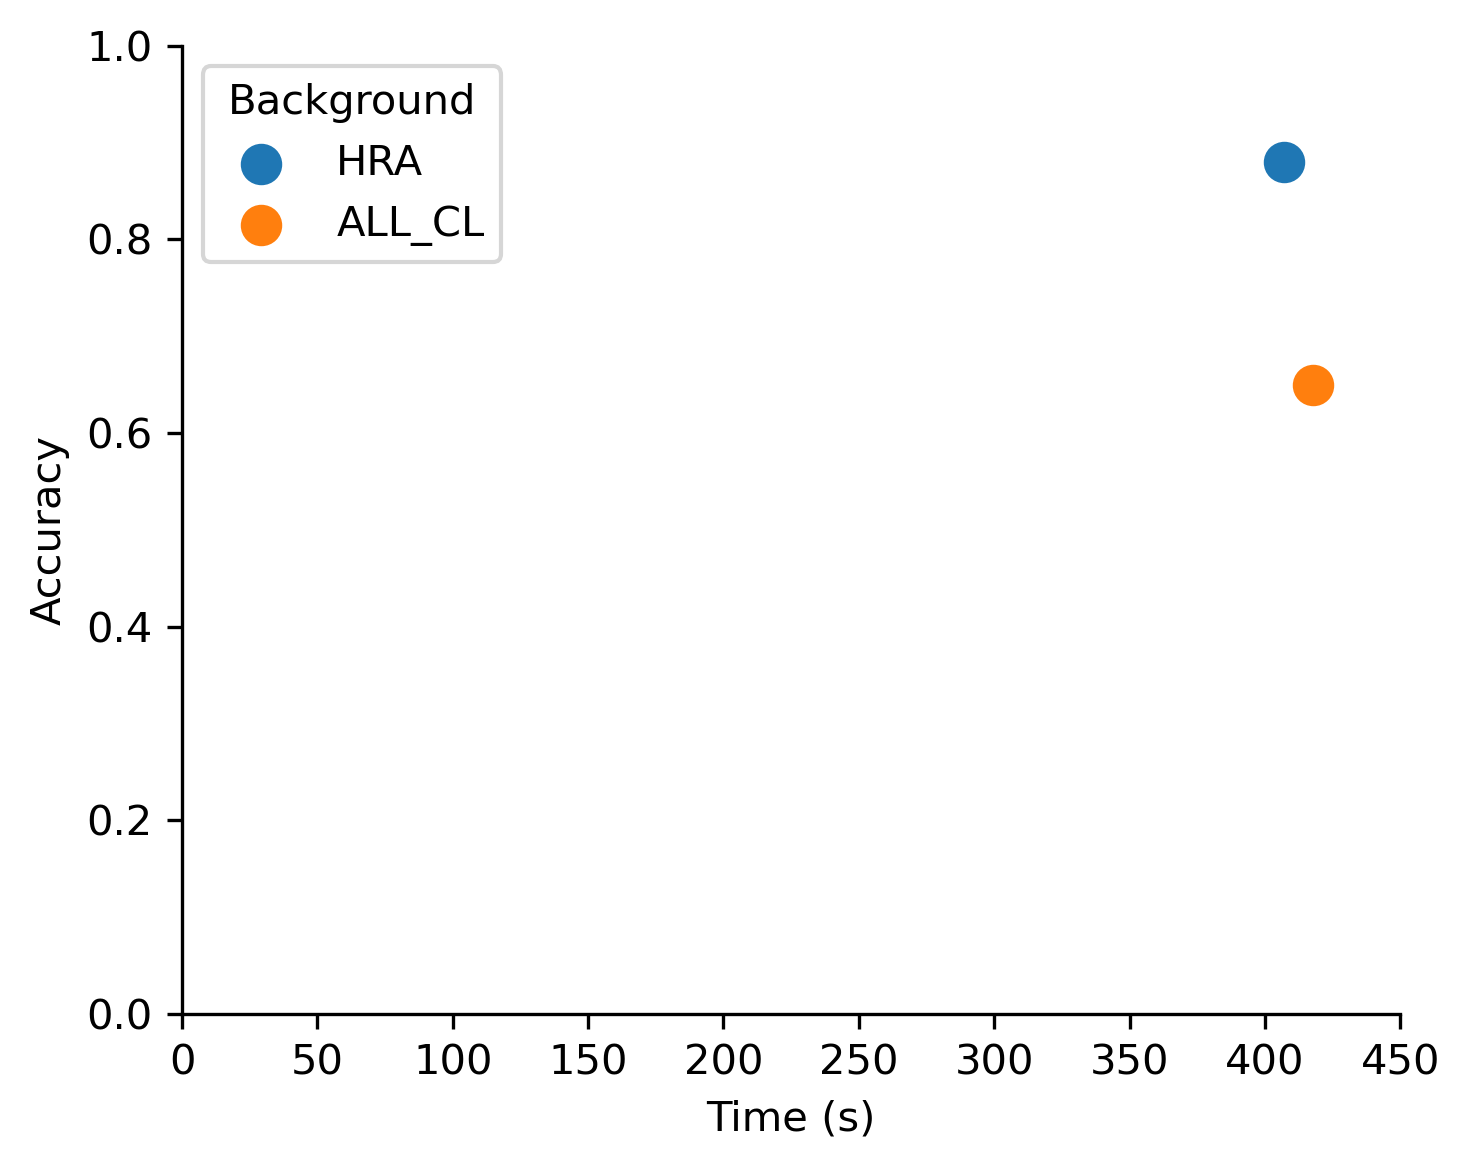

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4), dpi=300)

# Scatter by background
for bg in tradeoff["background"].unique():
    subset = tradeoff[tradeoff["background"] == bg]
    ax.scatter(
        subset["time"],
        subset["accuracy"],
        label=bg,
        s=80
    )

# Axis labels
ax.set_xlabel("Time (s)")
ax.set_ylabel("Accuracy")

# Axis limits
ax.set_xlim(0, 450)
ax.set_ylim(0, 1)

# Legend
ax.legend(title="Background")

# Style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
trade_off = pd.read_excel('trade_off_labeled.xlsx')

In [28]:
trade_off[['manual annotation','manual CLname','GPT-4 corrected annotation(complex with CL background)','label for complex strategy with CL background']]

,manual annotation,manual CLname,GPT-4 corrected annotation(complex with CL background),label for complex strategy with CL background
0,Intermediate B cell,transitional stage B cell,transitional stage B cell,fully match
1,Memory B cell,memory B cell,memory B cell,fully match
2,Naive B cell,naive B cell,naive B cell,fully match
3,Plasmablast,plasmablast,plasmablast,fully match
4,CD4+ Cytotoxic T,"CD4-positive, alpha-beta cytotoxic T cell","CD4-positive, alpha-beta cytotoxic T cell",fully match
...,...,...,...,...
551,Neurons,neuron,neural cell,partial mismatch
552,T cells,T cell,T cell,fully match
553,Dendrocytes,dendritic cell,oligodendrocyte,fully mismatch
554,Endothelial cells,endothelial cell,endothelial cell,fully match


In [30]:
import pandas as pd
import numpy as np

# Agreement score mapping
score_map = {
    "fully match": 1.0,
    "partial mismatch": 0.5,
    "fully mismatch": 0.0
}

# 1) Exclude rows where manual CLname or prediction is NA
filtered = trade_off.dropna(
    subset=["manual CLname", "GPT-4 corrected annotation(complex with CL background)"]
).copy()

# Use the *label* column (ontology-aware)
label_col = "label for complex strategy with CL background"

# 2) Map labels to numeric agreement score
filtered["agreement_score"] = filtered[label_col].map(score_map)

# 3) Per (tissue, dataset): mean agreement score
per_tissue_dataset = (
    filtered
    .groupby(["tissue", "dataset"], dropna=False)
    .agg(
        agreement_score=("agreement_score", "mean"),
        n=("agreement_score", "size")
    )
    .reset_index()
)

# 4) Block-B overall statistics (unweighted across tissue–dataset)
overall_avg = per_tissue_dataset["agreement_score"].mean()
overall_med = per_tissue_dataset["agreement_score"].median()

print("Per (tissue, dataset) agreement scores:")
print(per_tissue_dataset)

print("\nAverage agreement score across (tissue, dataset):", overall_avg)
print("Median agreement score across (tissue, dataset):", overall_med)


Per (tissue, dataset) agreement scores:
                              tissue      dataset  agreement_score   n
0                            Adipose      Azimuth         0.928571  14
1                    B cell lymphoma          BCL         0.857143   7
2                            Bladder           TS         1.000000   4
3                              Blood           TS         0.850000  10
4                        Bone Marrow      Azimuth         0.931034  29
5                        Bone Marrow           TS         0.916667   6
6                             Breast         GTEx         1.000000   3
7                             Breast   literature         0.937500   8
8                           Duodenum       mammal         1.000000   2
9                          Esophagus         GTEx         0.950000  10
10                         Esophagus   literature         0.888889   9
11                               Eye           TS         0.916667   6
12                               Fat 

In [32]:
import pandas as pd
import numpy as np

# Agreement score mapping
score_map = {
    "fully match": 1.0,
    "partial mismatch": 0.5,
    "fully mismatch": 0.0
}

# 1) Exclude rows where manual CLname or prediction is NA
filtered = trade_off.dropna(
    subset=["manual CLname"]
).copy()

# Use the *label* column (ontology-aware)
label_col = "label for complex strategy"

# 2) Map labels to numeric agreement score
filtered["agreement_score"] = filtered[label_col].map(score_map)

# 3) Per (tissue, dataset): mean agreement score
per_tissue_dataset = (
    filtered
    .groupby(["tissue", "dataset"], dropna=False)
    .agg(
        agreement_score=("agreement_score", "mean"),
        n=("agreement_score", "size")
    )
    .reset_index()
)

# 4) Block-B overall statistics (unweighted across tissue–dataset)
overall_avg = per_tissue_dataset["agreement_score"].mean()
overall_med = per_tissue_dataset["agreement_score"].median()

print("Per (tissue, dataset) agreement scores:")
print(per_tissue_dataset)

print("\nAverage agreement score across (tissue, dataset):", overall_avg)
print("Median agreement score across (tissue, dataset):", overall_med)

Per (tissue, dataset) agreement scores:
                              tissue      dataset  agreement_score   n
0                            Adipose      Azimuth         1.000000  14
1                    B cell lymphoma          BCL         0.785714   7
2                            Bladder           TS         1.000000   4
3                              Blood           TS         1.000000  10
4                        Bone Marrow      Azimuth         0.862069  29
5                        Bone Marrow           TS         1.000000   6
6                             Breast         GTEx         1.000000   3
7                             Breast   literature         1.000000   8
8                           Duodenum       mammal         1.000000   2
9                          Esophagus         GTEx         1.000000  10
10                         Esophagus   literature         1.000000   9
11                               Eye           TS         1.000000   6
12                               Fat 

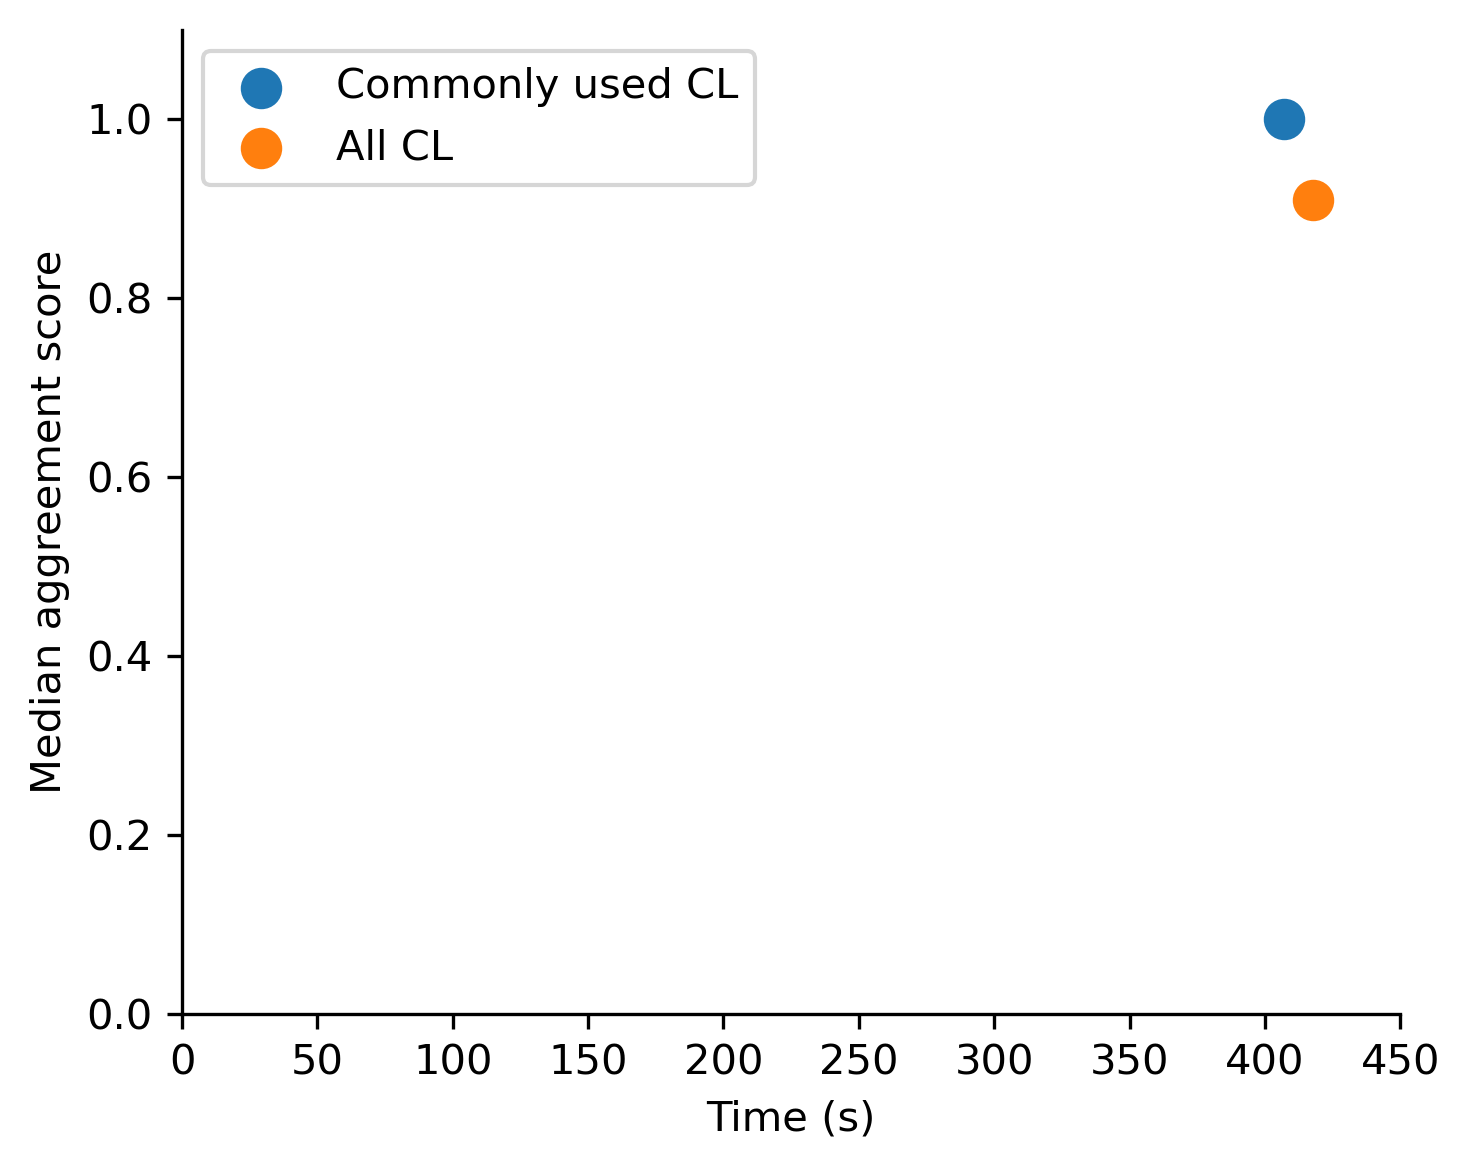

In [2]:

import matplotlib.pyplot as plt
import pandas as pd

tradeoff = pd.DataFrame({
    'background':['Commonly used CL','All CL'],
    'accuracy': [1,0.91],
    'time': [407.149564,417.593989]
})


fig, ax = plt.subplots(figsize=(5, 4), dpi=300)

# Scatter by background
for bg in tradeoff["background"].unique():
    subset = tradeoff[tradeoff["background"] == bg]
    ax.scatter(
        subset["time"],
        subset["accuracy"],
        label=bg,
        s=80
    )

# Axis labels
ax.set_xlabel("Time (s)")
ax.set_ylabel("Median aggreement score")

# Axis limits
ax.set_xlim(0, 450)
ax.set_ylim(0, 1.1)

# Legend
ax.legend(title="")

# Style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()